# Graph Neural Networks: Message Passing and Node Classification

Graph Neural Networks (GNNs) have revolutionized how we process relational and structured data. Unlike traditional neural networks that operate on fixed-size inputs like vectors or images, GNNs can handle arbitrarily structured graphs, making them ideal for social networks, molecular structures, knowledge graphs, and recommendation systems.

## What You Will Learn

1. **Graph Representation**: How to encode graphs as adjacency matrices and feature matrices
2. **Message Passing**: The fundamental mechanism behind GNNs
3. **Graph Convolutional Networks (GCN)**: Implementation from scratch
4. **Node Classification**: Predicting labels for nodes in a graph
5. **Visualization**: Understanding learned embeddings

In [1]:
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Circle, FancyArrowPatch
import matplotlib.patches as mpatches
from scipy.special import softmax

# Set random seed for reproducibility
np.random.seed(42)

# Style configuration
plt.rcParams['figure.figsize'] = (12, 8)
plt.rcParams['font.size'] = 11
plt.rcParams['axes.titlesize'] = 14
plt.rcParams['axes.labelsize'] = 12

## 1. Graph Representation

A graph $G = (V, E)$ consists of:
- **Nodes** $V = \{v_1, v_2, ..., v_n\}$: Entities in our network
- **Edges** $E \subseteq V \times V$: Relationships between entities

We represent a graph using:
- **Adjacency Matrix** $A \in \{0,1\}^{n \times n}$: Where $A_{ij} = 1$ if there is an edge from node $i$ to node $j$
- **Feature Matrix** $X \in \mathbb{R}^{n \times d}$: Where each row $x_i$ is a $d$-dimensional feature vector for node $i$

In [2]:
def create_karate_club_graph():
    """
    Create Zachary's Karate Club graph - a famous social network.
    
    This graph represents friendships between 34 members of a karate club
    that eventually split into two factions. It's a classic benchmark
    for community detection and node classification.
    """
    # Edge list for Karate Club (0-indexed)
    edges = [
        (0, 1), (0, 2), (0, 3), (0, 4), (0, 5), (0, 6), (0, 7), (0, 8),
        (0, 10), (0, 11), (0, 12), (0, 13), (0, 17), (0, 19), (0, 21), (0, 31),
        (1, 2), (1, 3), (1, 7), (1, 13), (1, 17), (1, 19), (1, 21), (1, 30),
        (2, 3), (2, 7), (2, 8), (2, 9), (2, 13), (2, 27), (2, 28), (2, 32),
        (3, 7), (3, 12), (3, 13), (4, 6), (4, 10), (5, 6), (5, 10), (5, 16),
        (6, 16), (8, 30), (8, 32), (8, 33), (9, 33), (13, 33), (14, 32), (14, 33),
        (15, 32), (15, 33), (18, 32), (18, 33), (19, 33), (20, 32), (20, 33),
        (22, 32), (22, 33), (23, 25), (23, 27), (23, 29), (23, 32), (23, 33),
        (24, 25), (24, 27), (24, 31), (25, 31), (26, 29), (26, 33), (27, 33),
        (28, 31), (28, 33), (29, 32), (29, 33), (30, 32), (30, 33), (31, 32),
        (31, 33), (32, 33)
    ]
    
    num_nodes = 34
    adj_matrix = np.zeros((num_nodes, num_nodes))
    
    for i, j in edges:
        adj_matrix[i, j] = 1
        adj_matrix[j, i] = 1  # Undirected graph
    
    # True community labels (0 = Mr. Hi's faction, 1 = Officer's faction)
    labels = np.array([0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0,
                       1, 0, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1])
    
    return adj_matrix, labels

# Create the graph
A, true_labels = create_karate_club_graph()
num_nodes = A.shape[0]

print(f"Number of nodes: {num_nodes}")
print(f"Number of edges: {int(np.sum(A) / 2)}")
print(f"Average degree: {np.mean(np.sum(A, axis=1)):.2f}")

Number of nodes: 34
Number of edges: 78
Average degree: 4.59


In [3]:
def create_node_features(adj_matrix, feature_dim=16):
    """
    Create initial node features based on structural properties.
    
    In real applications, nodes often have inherent features (e.g., user profiles,
    molecular properties). Here we create features from graph structure:
    - Degree (number of connections)
    - Local clustering coefficient
    - Random embeddings for additional dimensions
    """
    num_nodes = adj_matrix.shape[0]
    features = np.zeros((num_nodes, feature_dim))
    
    # Feature 1: Normalized degree
    degrees = np.sum(adj_matrix, axis=1)
    features[:, 0] = degrees / np.max(degrees)
    
    # Feature 2: Local clustering coefficient
    for i in range(num_nodes):
        neighbors = np.where(adj_matrix[i] == 1)[0]
        k = len(neighbors)
        if k < 2:
            features[i, 1] = 0
        else:
            # Count edges between neighbors
            edges_between = 0
            for j in range(len(neighbors)):
                for l in range(j + 1, len(neighbors)):
                    edges_between += adj_matrix[neighbors[j], neighbors[l]]
            features[i, 1] = 2 * edges_between / (k * (k - 1))
    
    # Features 3-16: Random initialization (will be learned)
    features[:, 2:] = np.random.randn(num_nodes, feature_dim - 2) * 0.1
    
    return features

# Create node features
X = create_node_features(A, feature_dim=16)
print(f"Feature matrix shape: {X.shape}")
print(f"Sample features for node 0: {X[0, :4]}")

Feature matrix shape: (34, 16)
Sample features for node 0: [ 0.94117647  0.15        0.04967142 -0.01382643]


## 2. Message Passing: The Core of GNNs

The key insight of GNNs is that a node's representation should depend on its neighbors. This is implemented through **message passing**:

$$h_v^{(l+1)} = \text{UPDATE}\left(h_v^{(l)}, \text{AGGREGATE}\left(\{h_u^{(l)} : u \in \mathcal{N}(v)\}\right)\right)$$

Where:
- $h_v^{(l)}$ is the representation of node $v$ at layer $l$
- $\mathcal{N}(v)$ is the set of neighbors of node $v$
- AGGREGATE collects information from neighbors
- UPDATE combines the aggregated information with the node's own representation

### Graph Convolutional Network (GCN) Layer

The GCN layer uses a specific form of message passing:

$$H^{(l+1)} = \sigma\left(\tilde{D}^{-1/2} \tilde{A} \tilde{D}^{-1/2} H^{(l)} W^{(l)}\right)$$

Where:
- $\tilde{A} = A + I$ (adjacency matrix with self-loops)
- $\tilde{D}_{ii} = \sum_j \tilde{A}_{ij}$ (degree matrix)
- $W^{(l)}$ is a learnable weight matrix
- $\sigma$ is a nonlinear activation (typically ReLU)

In [4]:
class GCNLayer:
    """
    Graph Convolutional Network Layer.
    
    Implements the spectral convolution operation on graphs.
    The symmetric normalization (D^{-1/2} A D^{-1/2}) ensures that
    features are scaled by the geometric mean of degrees, which
    prevents numerical instabilities during training.
    """
    def __init__(self, input_dim, output_dim):
        # Xavier initialization for better gradient flow
        scale = np.sqrt(2.0 / (input_dim + output_dim))
        self.W = np.random.randn(input_dim, output_dim) * scale
        self.b = np.zeros(output_dim)
        
        # Gradient storage
        self.dW = None
        self.db = None
        
    def forward(self, X, A_norm, training=True):
        """
        Forward pass through the GCN layer.
        
        Parameters:
        -----------
        X : ndarray of shape (num_nodes, input_dim)
            Input node features
        A_norm : ndarray of shape (num_nodes, num_nodes)
            Normalized adjacency matrix with self-loops
        
        Returns:
        --------
        H : ndarray of shape (num_nodes, output_dim)
            Output node representations
        """
        self.X = X
        self.A_norm = A_norm
        
        # Message passing: aggregate neighbor features
        # H = A_norm @ X @ W + b
        self.AX = A_norm @ X  # Aggregate
        self.Z = self.AX @ self.W + self.b  # Transform
        
        # ReLU activation
        self.H = np.maximum(0, self.Z)
        
        return self.H
    
    def backward(self, dH):
        """
        Backward pass for gradient computation.
        """
        # ReLU gradient
        dZ = dH * (self.Z > 0)
        
        # Parameter gradients
        self.dW = self.AX.T @ dZ
        self.db = np.sum(dZ, axis=0)
        
        # Input gradient (for previous layer)
        dAX = dZ @ self.W.T
        dX = self.A_norm.T @ dAX
        
        return dX


def normalize_adjacency(A):
    """
    Compute the normalized adjacency matrix with self-loops.
    
    A_norm = D^{-1/2} (A + I) D^{-1/2}
    
    This symmetric normalization is crucial for:
    1. Numerical stability (prevents vanishing/exploding activations)
    2. Self-information retention (via self-loops)
    3. Proper aggregation weighting (by degree)
    """
    # Add self-loops
    A_hat = A + np.eye(A.shape[0])
    
    # Compute degree matrix
    D = np.diag(np.sum(A_hat, axis=1))
    
    # D^{-1/2}
    D_inv_sqrt = np.diag(1.0 / np.sqrt(np.diag(D)))
    
    # Symmetric normalization
    A_norm = D_inv_sqrt @ A_hat @ D_inv_sqrt
    
    return A_norm

# Normalize adjacency matrix
A_norm = normalize_adjacency(A)
print(f"Normalized adjacency matrix shape: {A_norm.shape}")
print(f"Sum of row 0: {np.sum(A_norm[0]):.4f}")

Normalized adjacency matrix shape: (34, 34)
Sum of row 0: 1.8708


## 3. Building a Two-Layer GCN

We'll build a simple two-layer GCN for node classification:

$$Z = \text{softmax}\left(\hat{A} \cdot \text{ReLU}\left(\hat{A} X W^{(0)}\right) W^{(1)}\right)$$

The architecture:
- **Input**: Node features $X \in \mathbb{R}^{n \times 16}$
- **Hidden Layer**: GCN layer with 16 hidden units + ReLU
- **Output Layer**: GCN layer with 2 units (for 2 classes) + Softmax

In [5]:
class GCN:
    """
    Two-layer Graph Convolutional Network for node classification.
    
    Architecture:
    Input (16) -> GCN (16) -> ReLU -> GCN (2) -> Softmax
    """
    def __init__(self, input_dim, hidden_dim, output_dim):
        self.layer1 = GCNLayer(input_dim, hidden_dim)
        self.layer2 = GCNLayer(hidden_dim, output_dim)
        
    def forward(self, X, A_norm):
        """
        Forward pass through the network.
        
        Returns both the hidden representations (for visualization)
        and the class probabilities.
        """
        # First GCN layer with ReLU
        self.H1 = self.layer1.forward(X, A_norm)
        
        # Second GCN layer (no ReLU, use softmax for classification)
        self.Z = self.layer2.forward(self.H1, A_norm)
        
        # Softmax for class probabilities
        self.probs = softmax(self.Z, axis=1)
        
        return self.probs
    
    def backward(self, labels, mask):
        """
        Backward pass using cross-entropy loss.
        
        Parameters:
        -----------
        labels : ndarray of shape (num_nodes,)
            True class labels
        mask : ndarray of shape (num_nodes,)
            Boolean mask indicating which nodes are in training set
        """
        num_train = np.sum(mask)
        
        # Cross-entropy gradient
        dZ = self.probs.copy()
        dZ[np.arange(len(labels)), labels] -= 1
        dZ[~mask] = 0  # Zero out gradients for non-training nodes
        dZ /= num_train
        
        # Backprop through layer 2
        # Note: layer2 has no ReLU, so we pass dZ directly
        dH1 = self.layer2.A_norm.T @ (dZ @ self.layer2.W.T)
        self.layer2.dW = self.layer2.AX.T @ dZ
        self.layer2.db = np.sum(dZ, axis=0)
        
        # Backprop through layer 1
        _ = self.layer1.backward(dH1)
        
    def update(self, lr):
        """
        Update parameters using gradient descent.
        """
        self.layer1.W -= lr * self.layer1.dW
        self.layer1.b -= lr * self.layer1.db
        self.layer2.W -= lr * self.layer2.dW
        self.layer2.b -= lr * self.layer2.db


def cross_entropy_loss(probs, labels, mask):
    """
    Compute cross-entropy loss for masked nodes.
    """
    log_probs = -np.log(probs[np.arange(len(labels)), labels] + 1e-10)
    return np.mean(log_probs[mask])


def accuracy(probs, labels, mask):
    """
    Compute classification accuracy for masked nodes.
    """
    preds = np.argmax(probs, axis=1)
    correct = (preds == labels) & mask
    return np.sum(correct) / np.sum(mask)

In [6]:
# Create train/test split
# In semi-supervised learning, we only use a few labeled nodes for training
np.random.seed(42)
train_mask = np.zeros(num_nodes, dtype=bool)
# Use 4 nodes per class for training (very limited supervision)
for c in [0, 1]:
    class_nodes = np.where(true_labels == c)[0]
    train_idx = np.random.choice(class_nodes, size=4, replace=False)
    train_mask[train_idx] = True

test_mask = ~train_mask

print(f"Training nodes: {np.sum(train_mask)} ({100*np.mean(train_mask):.1f}%)")
print(f"Test nodes: {np.sum(test_mask)} ({100*np.mean(test_mask):.1f}%)")

Training nodes: 8 (23.5%)
Test nodes: 26 (76.5%)


In [7]:
# Initialize model
model = GCN(input_dim=16, hidden_dim=16, output_dim=2)

# Training parameters
num_epochs = 200
learning_rate = 0.1

# Training history
history = {
    'train_loss': [],
    'train_acc': [],
    'test_acc': []
}

# Training loop
print("Training GCN...")
print("-" * 50)

for epoch in range(num_epochs):
    # Forward pass
    probs = model.forward(X, A_norm)
    
    # Compute loss and accuracy
    loss = cross_entropy_loss(probs, true_labels, train_mask)
    train_acc = accuracy(probs, true_labels, train_mask)
    test_acc = accuracy(probs, true_labels, test_mask)
    
    history['train_loss'].append(loss)
    history['train_acc'].append(train_acc)
    history['test_acc'].append(test_acc)
    
    # Backward pass
    model.backward(true_labels, train_mask)
    
    # Update parameters
    model.update(learning_rate)
    
    if (epoch + 1) % 50 == 0:
        print(f"Epoch {epoch+1:3d}: Loss = {loss:.4f}, Train Acc = {train_acc:.4f}, Test Acc = {test_acc:.4f}")

print("-" * 50)
print(f"Final Test Accuracy: {history['test_acc'][-1]:.4f}")

Training GCN...
--------------------------------------------------
Epoch  50: Loss = 0.6828, Train Acc = 0.3750, Test Acc = 0.7308
Epoch 100: Loss = 0.6730, Train Acc = 0.7500, Test Acc = 0.6923
Epoch 150: Loss = 0.6641, Train Acc = 0.7500, Test Acc = 0.6154
Epoch 200: Loss = 0.6541, Train Acc = 0.7500, Test Acc = 0.6154
--------------------------------------------------
Final Test Accuracy: 0.6154


## 4. Visualizing Training Progress and Results

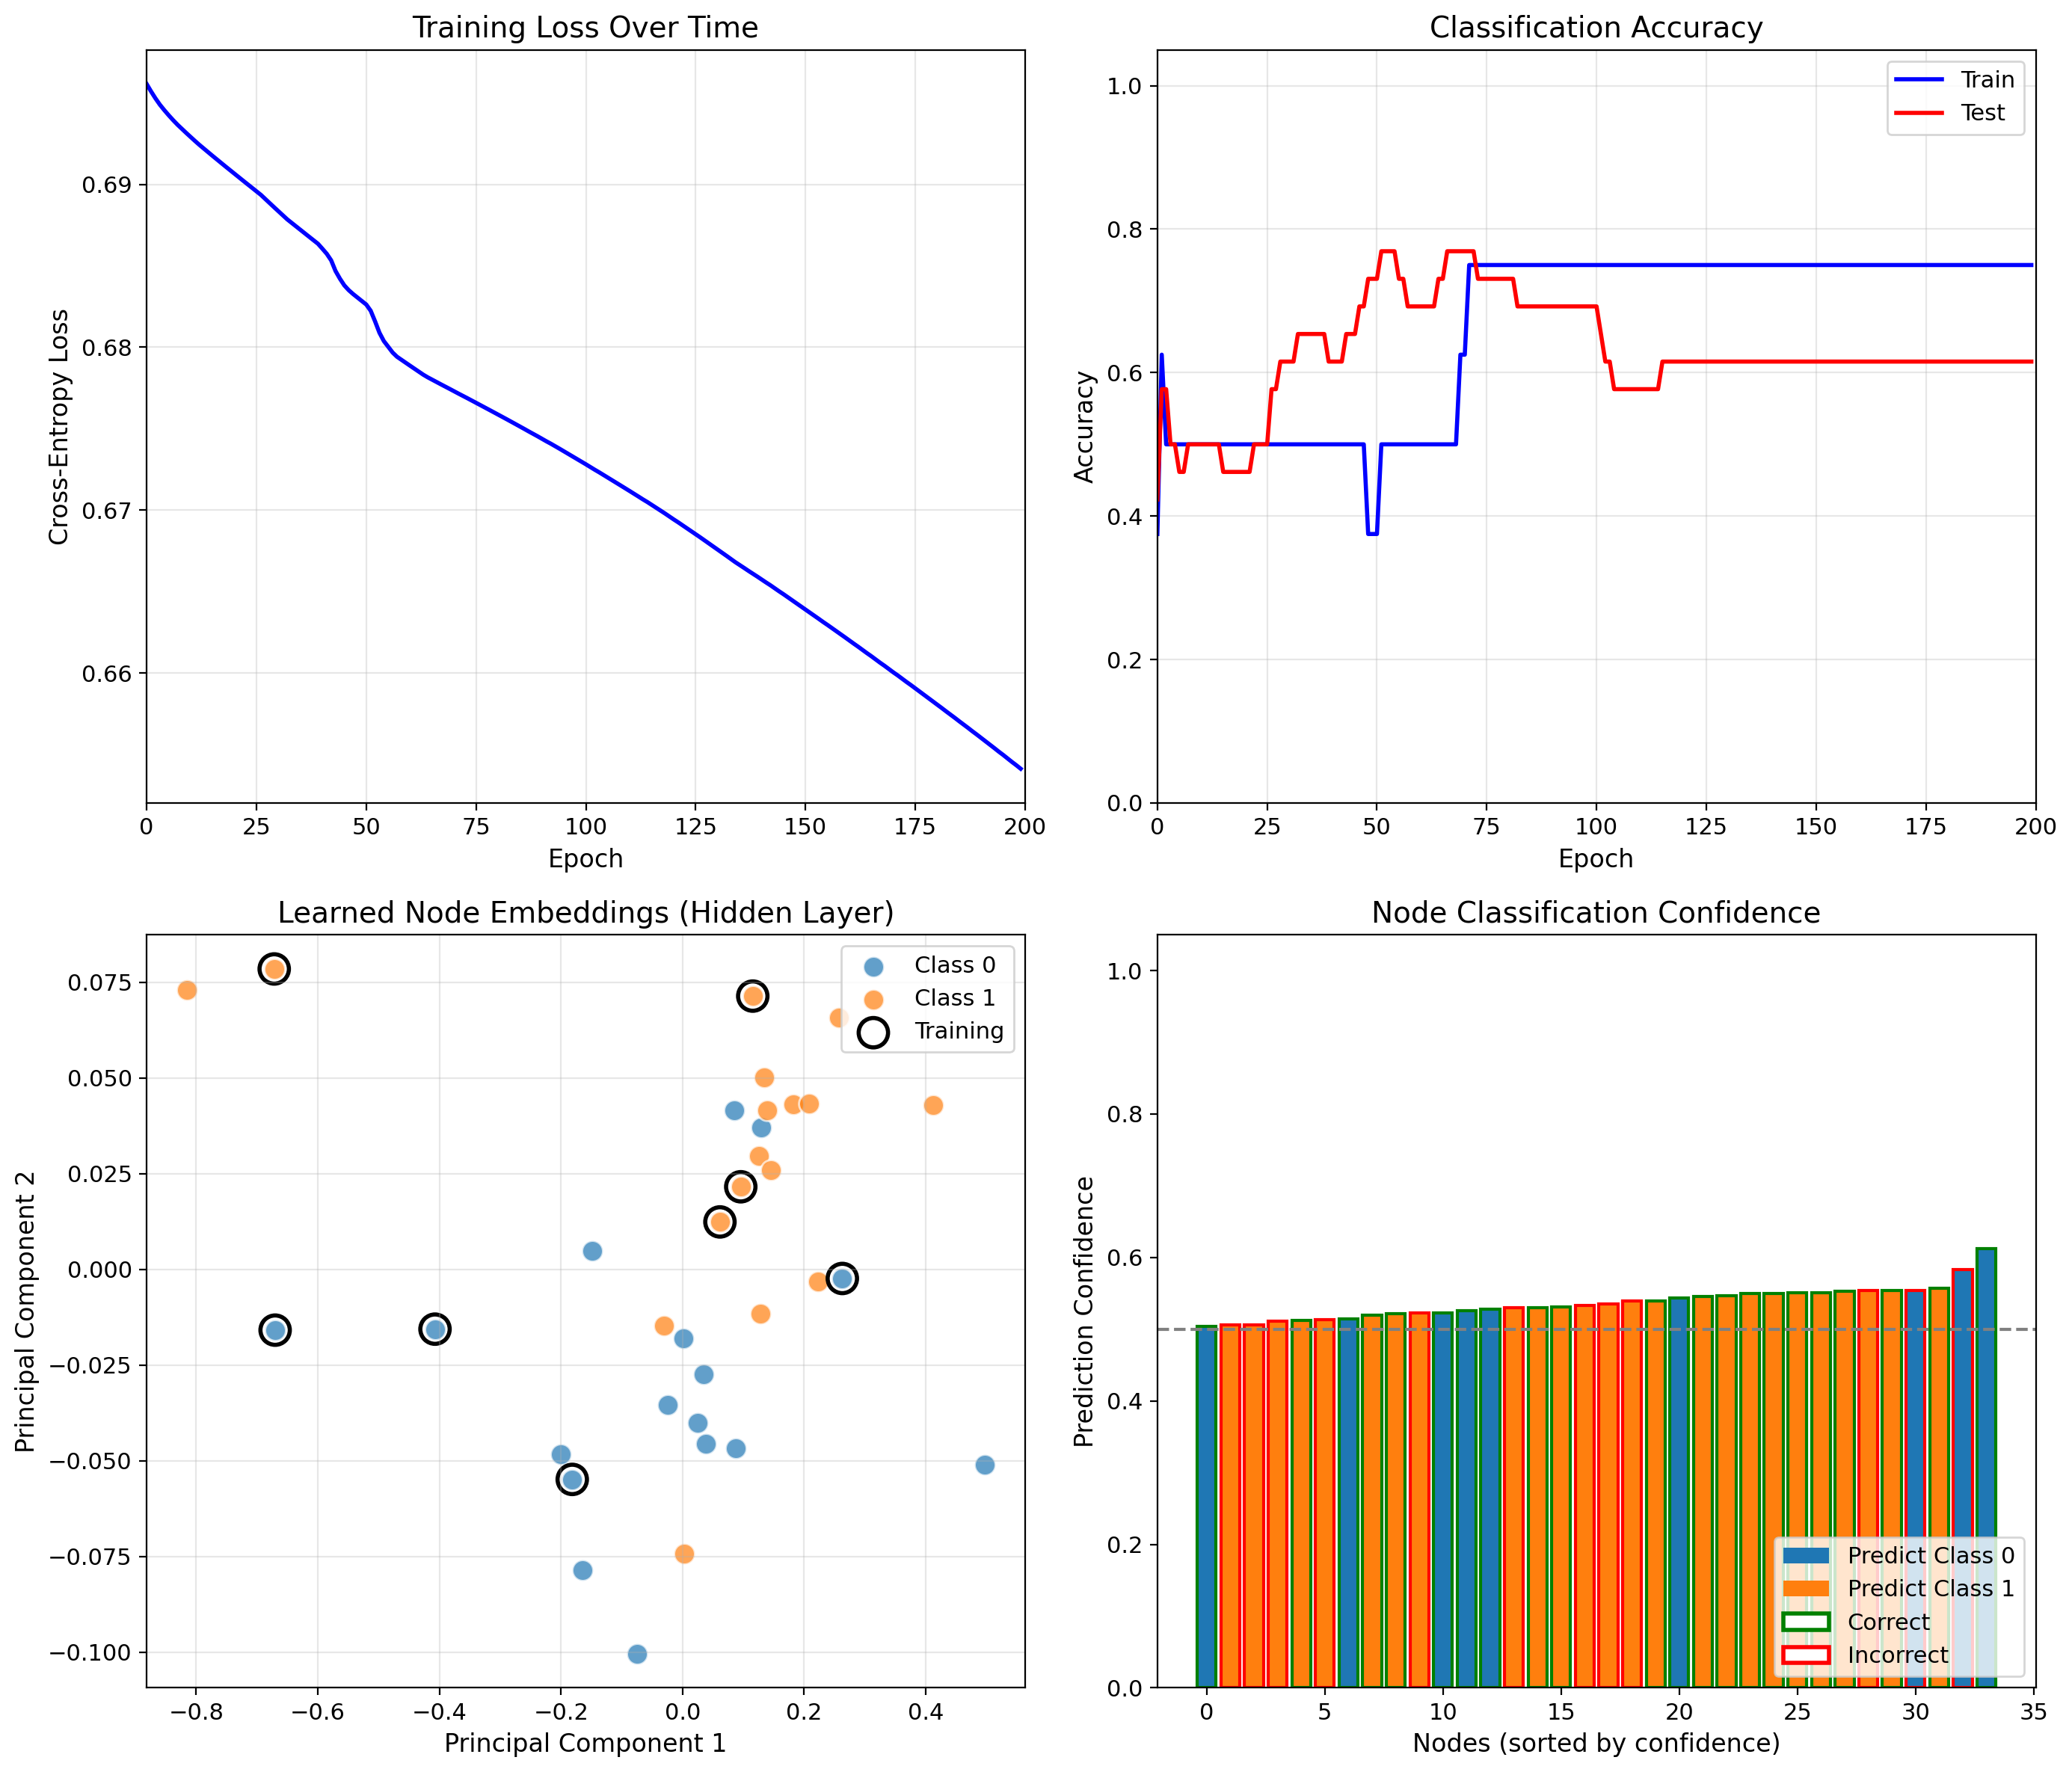


Figure saved as 'graph_neural_networks_training.png'


In [8]:
# Create visualization
fig, axes = plt.subplots(2, 2, figsize=(14, 12))

# Plot 1: Training Loss
ax1 = axes[0, 0]
ax1.plot(history['train_loss'], 'b-', linewidth=2)
ax1.set_xlabel('Epoch')
ax1.set_ylabel('Cross-Entropy Loss')
ax1.set_title('Training Loss Over Time')
ax1.grid(True, alpha=0.3)
ax1.set_xlim(0, num_epochs)

# Plot 2: Accuracy
ax2 = axes[0, 1]
ax2.plot(history['train_acc'], 'b-', label='Train', linewidth=2)
ax2.plot(history['test_acc'], 'r-', label='Test', linewidth=2)
ax2.set_xlabel('Epoch')
ax2.set_ylabel('Accuracy')
ax2.set_title('Classification Accuracy')
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_xlim(0, num_epochs)
ax2.set_ylim(0, 1.05)

# Plot 3: Learned Node Embeddings (Hidden Layer)
ax3 = axes[1, 0]

# Get hidden representations
_ = model.forward(X, A_norm)
H = model.H1  # Hidden layer activations

# Use PCA-like projection for 2D visualization
# Simple projection onto first 2 principal components
H_centered = H - H.mean(axis=0)
U, S, Vt = np.linalg.svd(H_centered, full_matrices=False)
H_2d = H_centered @ Vt[:2].T

colors = ['#1f77b4', '#ff7f0e']  # Blue for class 0, Orange for class 1
for c in [0, 1]:
    mask_c = true_labels == c
    ax3.scatter(H_2d[mask_c, 0], H_2d[mask_c, 1], 
                c=colors[c], label=f'Class {c}', alpha=0.7, s=100, edgecolors='white')

# Mark training nodes
ax3.scatter(H_2d[train_mask, 0], H_2d[train_mask, 1], 
            facecolors='none', edgecolors='black', s=200, linewidths=2, label='Training')

ax3.set_xlabel('Principal Component 1')
ax3.set_ylabel('Principal Component 2')
ax3.set_title('Learned Node Embeddings (Hidden Layer)')
ax3.legend()
ax3.grid(True, alpha=0.3)

# Plot 4: Prediction Confidence
ax4 = axes[1, 1]

# Final predictions
final_probs = model.forward(X, A_norm)
predicted_labels = np.argmax(final_probs, axis=1)
confidence = np.max(final_probs, axis=1)

# Sort by confidence for better visualization
sort_idx = np.argsort(confidence)

bar_colors = [colors[predicted_labels[i]] for i in sort_idx]
correct = predicted_labels == true_labels
edge_colors = ['green' if correct[i] else 'red' for i in sort_idx]

bars = ax4.bar(range(num_nodes), confidence[sort_idx], color=bar_colors, 
               edgecolor=edge_colors, linewidth=1.5)
ax4.axhline(y=0.5, color='gray', linestyle='--', label='Random baseline')
ax4.set_xlabel('Nodes (sorted by confidence)')
ax4.set_ylabel('Prediction Confidence')
ax4.set_title('Node Classification Confidence')

# Legend
from matplotlib.patches import Patch
legend_elements = [
    Patch(facecolor=colors[0], label='Predict Class 0'),
    Patch(facecolor=colors[1], label='Predict Class 1'),
    Patch(facecolor='white', edgecolor='green', linewidth=2, label='Correct'),
    Patch(facecolor='white', edgecolor='red', linewidth=2, label='Incorrect')
]
ax4.legend(handles=legend_elements, loc='lower right')
ax4.set_ylim(0, 1.05)

plt.tight_layout()
plt.savefig('graph_neural_networks_training.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\nFigure saved as 'graph_neural_networks_training.png'")

## 5. Visualizing the Graph with Predictions

In [9]:
def spring_layout(A, iterations=50, k=1.0):
    """
    Compute node positions using Fruchterman-Reingold force-directed layout.
    
    This algorithm treats edges as springs and nodes as repelling particles,
    finding an equilibrium that reveals graph structure.
    """
    n = A.shape[0]
    
    # Initialize random positions
    pos = np.random.rand(n, 2) * 2 - 1
    
    # Optimal distance between nodes
    area = 4.0  # Total area
    k = np.sqrt(area / n) * k
    
    t = 1.0  # Temperature (step size)
    dt = t / (iterations + 1)
    
    for _ in range(iterations):
        # Calculate pairwise differences
        diff = pos[:, np.newaxis, :] - pos[np.newaxis, :, :]
        dist = np.sqrt(np.sum(diff**2, axis=2) + 1e-10)
        
        # Repulsive forces (all pairs)
        repulsive = (k**2 / dist)[:, :, np.newaxis] * (diff / dist[:, :, np.newaxis])
        repulsive = np.nan_to_num(repulsive)  # Handle self-pairs
        f_repulsive = np.sum(repulsive, axis=1)
        
        # Attractive forces (only connected pairs)
        attractive = (dist / k)[:, :, np.newaxis] * (diff / dist[:, :, np.newaxis])
        attractive = attractive * A[:, :, np.newaxis]
        f_attractive = np.sum(attractive, axis=1)
        
        # Total force
        force = f_repulsive - f_attractive
        
        # Normalize and apply with temperature
        force_mag = np.sqrt(np.sum(force**2, axis=1, keepdims=True)) + 1e-10
        pos += (force / force_mag) * np.minimum(force_mag, t)
        
        # Cool down
        t -= dt
    
    # Normalize to [0, 1]
    pos = (pos - pos.min(axis=0)) / (pos.max(axis=0) - pos.min(axis=0))
    
    return pos

# Compute layout
np.random.seed(42)
pos = spring_layout(A, iterations=100)

print("Layout computed successfully!")

Layout computed successfully!


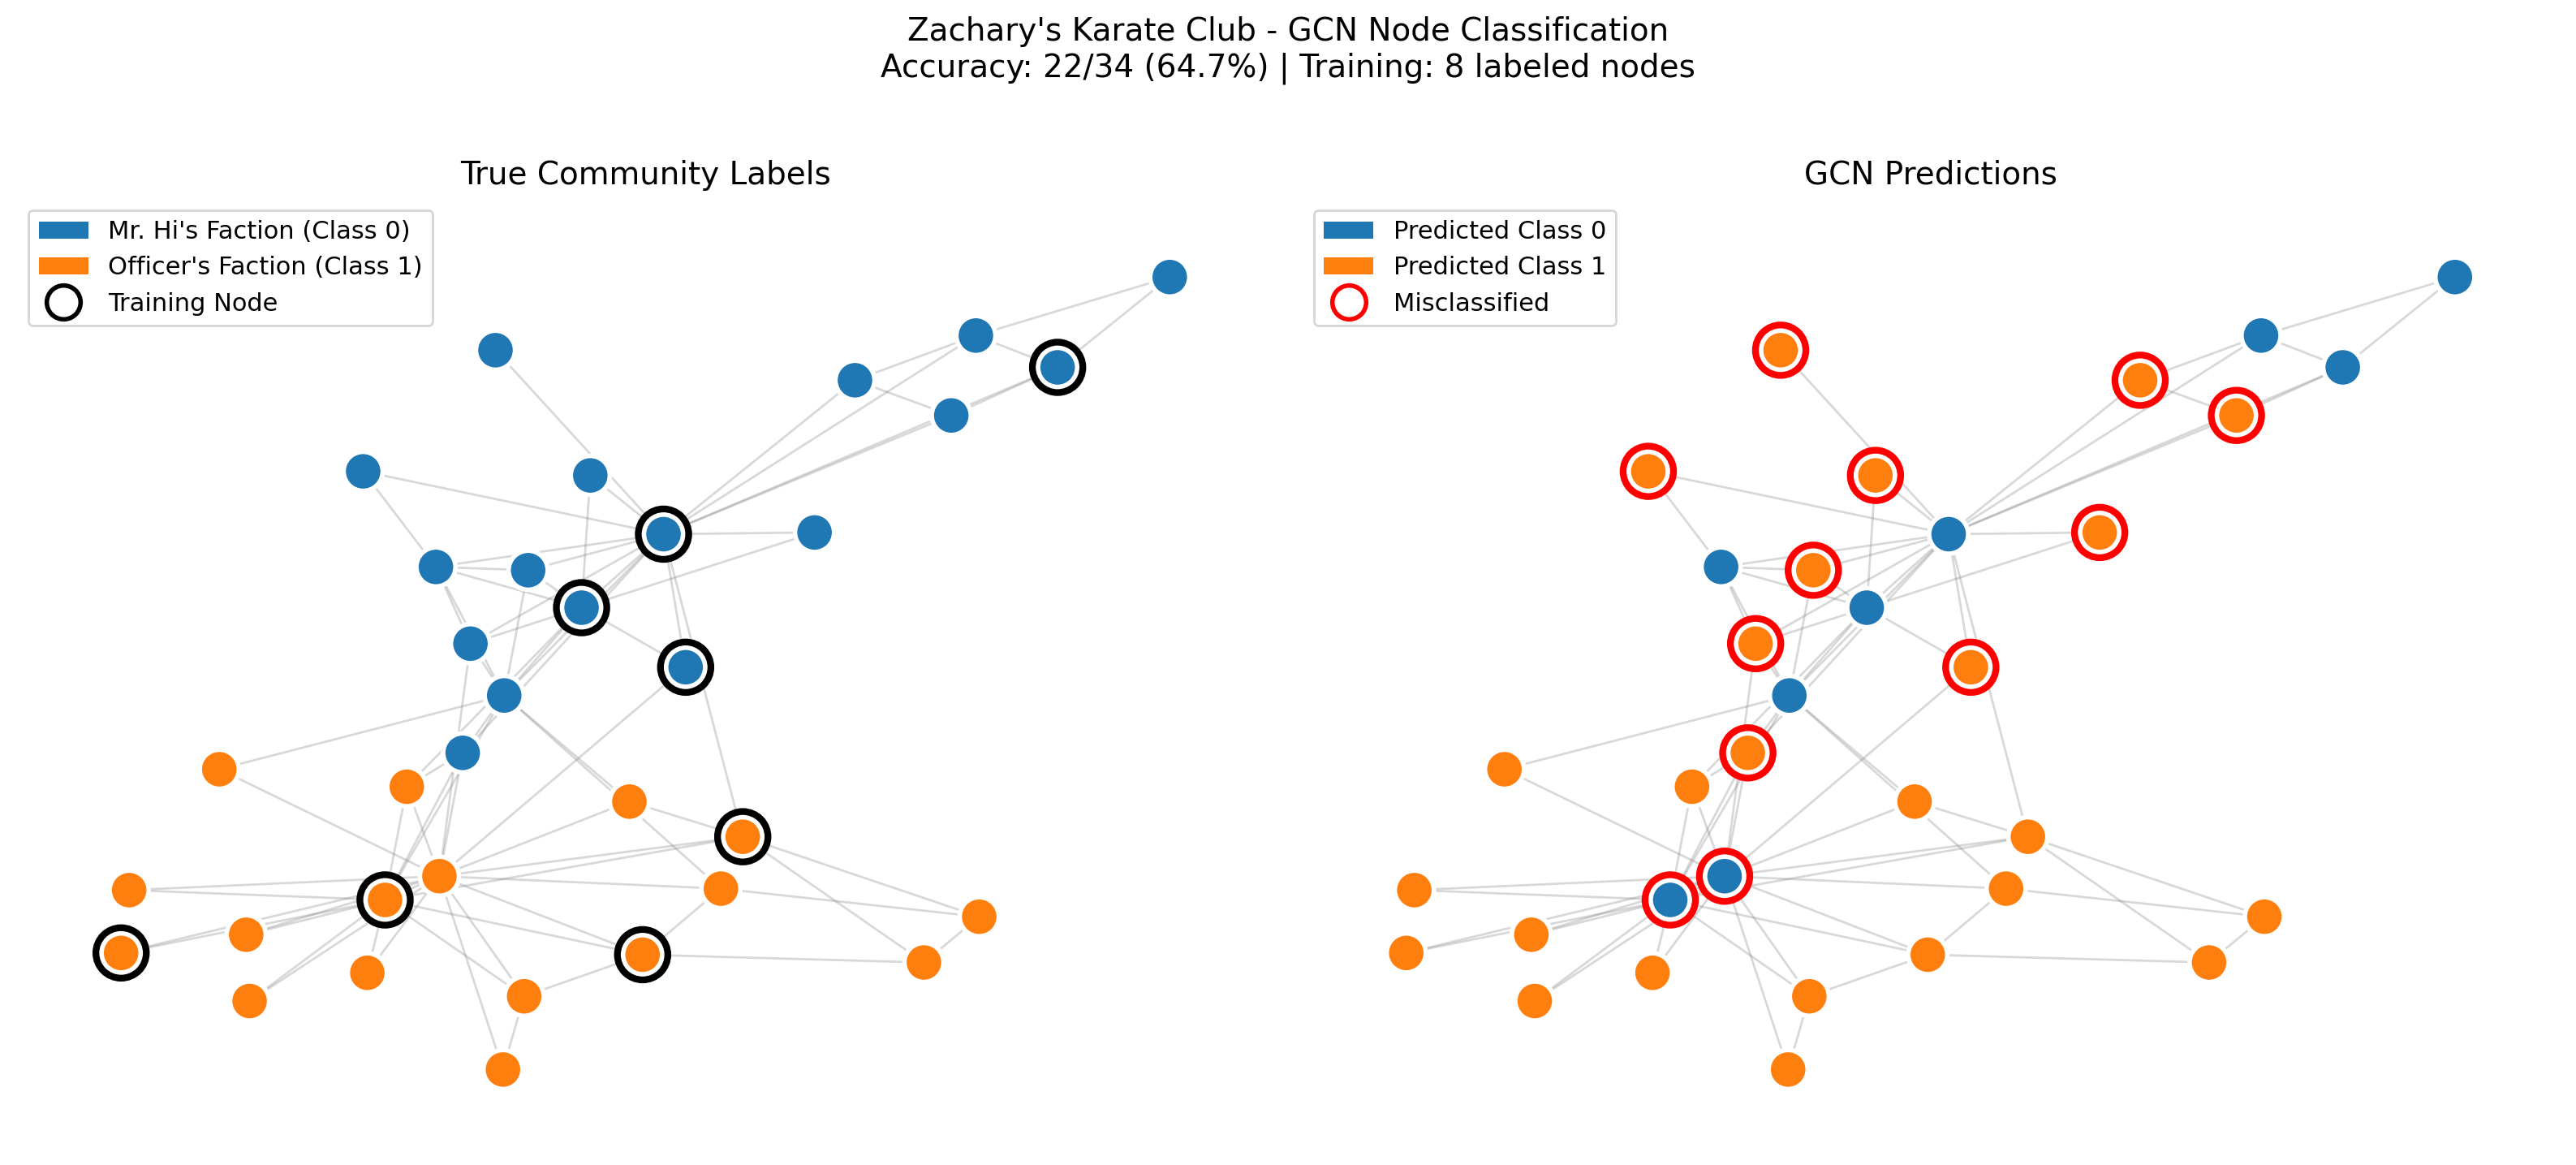


Figure saved as 'graph_neural_networks_graph.png'


In [10]:
# Create graph visualization
fig, axes = plt.subplots(1, 2, figsize=(16, 7))

# Plot 1: True Labels
ax1 = axes[0]
ax1.set_title('True Community Labels', fontsize=14)

# Draw edges
for i in range(num_nodes):
    for j in range(i+1, num_nodes):
        if A[i, j] == 1:
            ax1.plot([pos[i, 0], pos[j, 0]], [pos[i, 1], pos[j, 1]], 
                     'gray', alpha=0.3, linewidth=1)

# Draw nodes
node_colors_true = [colors[true_labels[i]] for i in range(num_nodes)]
scatter1 = ax1.scatter(pos[:, 0], pos[:, 1], c=node_colors_true, 
                       s=300, edgecolors='white', linewidths=2, zorder=5)

# Label nodes
for i in range(num_nodes):
    ax1.annotate(str(i), (pos[i, 0], pos[i, 1]), 
                 ha='center', va='center', fontsize=8, fontweight='bold', color='white')

# Mark training nodes
train_idx = np.where(train_mask)[0]
ax1.scatter(pos[train_idx, 0], pos[train_idx, 1], 
            facecolors='none', edgecolors='black', s=500, linewidths=3, zorder=6)

ax1.set_xlim(-0.1, 1.1)
ax1.set_ylim(-0.1, 1.1)
ax1.axis('off')

# Legend
legend_elements = [
    Patch(facecolor=colors[0], label="Mr. Hi's Faction (Class 0)"),
    Patch(facecolor=colors[1], label="Officer's Faction (Class 1)"),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='w',
               markeredgecolor='black', markersize=15, markeredgewidth=2, label='Training Node')
]
ax1.legend(handles=legend_elements, loc='upper left')

# Plot 2: GCN Predictions
ax2 = axes[1]
ax2.set_title('GCN Predictions', fontsize=14)

# Draw edges
for i in range(num_nodes):
    for j in range(i+1, num_nodes):
        if A[i, j] == 1:
            ax2.plot([pos[i, 0], pos[j, 0]], [pos[i, 1], pos[j, 1]], 
                     'gray', alpha=0.3, linewidth=1)

# Draw nodes with predicted colors
node_colors_pred = [colors[predicted_labels[i]] for i in range(num_nodes)]
scatter2 = ax2.scatter(pos[:, 0], pos[:, 1], c=node_colors_pred, 
                       s=300, edgecolors='white', linewidths=2, zorder=5)

# Label nodes
for i in range(num_nodes):
    ax2.annotate(str(i), (pos[i, 0], pos[i, 1]), 
                 ha='center', va='center', fontsize=8, fontweight='bold', color='white')

# Mark incorrect predictions
incorrect = np.where(predicted_labels != true_labels)[0]
if len(incorrect) > 0:
    ax2.scatter(pos[incorrect, 0], pos[incorrect, 1], 
                facecolors='none', edgecolors='red', s=500, linewidths=3, zorder=6)

ax2.set_xlim(-0.1, 1.1)
ax2.set_ylim(-0.1, 1.1)
ax2.axis('off')

# Legend
legend_elements = [
    Patch(facecolor=colors[0], label='Predicted Class 0'),
    Patch(facecolor=colors[1], label='Predicted Class 1'),
    plt.Line2D([0], [0], marker='o', color='w', markerfacecolor='w',
               markeredgecolor='red', markersize=15, markeredgewidth=2, label='Misclassified')
]
ax2.legend(handles=legend_elements, loc='upper left')

# Summary statistics
num_correct = np.sum(predicted_labels == true_labels)
num_incorrect = num_nodes - num_correct
fig.suptitle(f'Zachary\'s Karate Club - GCN Node Classification\n'
             f'Accuracy: {num_correct}/{num_nodes} ({100*num_correct/num_nodes:.1f}%) | '
             f'Training: {np.sum(train_mask)} labeled nodes', fontsize=14, y=1.02)

plt.tight_layout()
plt.savefig('graph_neural_networks_graph.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\nFigure saved as 'graph_neural_networks_graph.png'")

## 6. Understanding Message Passing Visually

Let's visualize how information propagates through the network during message passing.

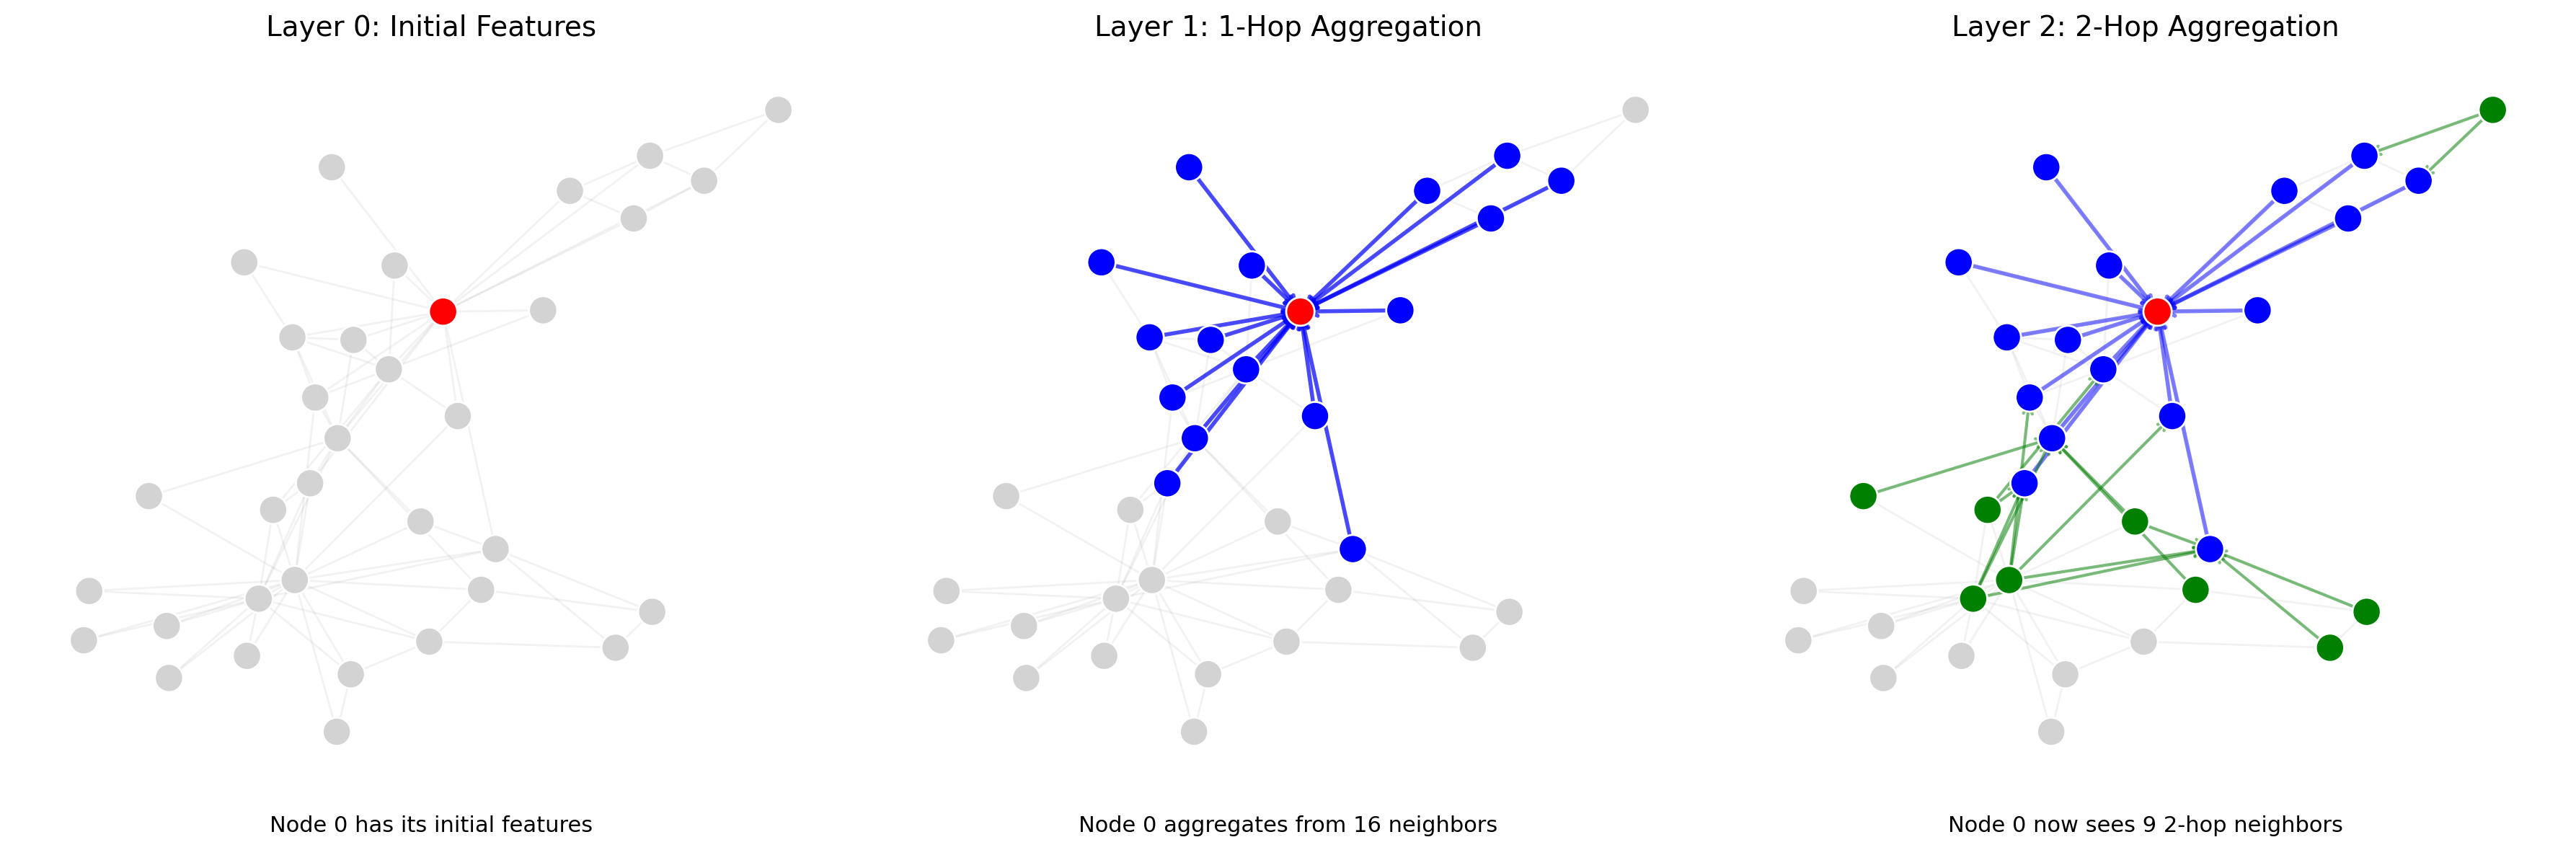


Figure saved as 'graph_neural_networks_message_passing.png'


In [11]:
# Visualize message passing from node 0
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# Select a central node (Mr. Hi = node 0)
center_node = 0

# Get 1-hop and 2-hop neighbors
neighbors_1hop = np.where(A[center_node] == 1)[0]
neighbors_2hop = set()
for n in neighbors_1hop:
    neighbors_2hop.update(np.where(A[n] == 1)[0])
neighbors_2hop = np.array([n for n in neighbors_2hop if n != center_node and n not in neighbors_1hop])

# Layer 0: Initial Features
ax = axes[0]
ax.set_title('Layer 0: Initial Features', fontsize=14)

# Draw all edges faintly
for i in range(num_nodes):
    for j in range(i+1, num_nodes):
        if A[i, j] == 1:
            ax.plot([pos[i, 0], pos[j, 0]], [pos[i, 1], pos[j, 1]], 
                    'gray', alpha=0.1, linewidth=1)

# Draw nodes
node_colors = ['lightgray'] * num_nodes
node_colors[center_node] = 'red'
ax.scatter(pos[:, 0], pos[:, 1], c=node_colors, s=200, edgecolors='white', linewidths=1, zorder=5)
ax.annotate(f'{center_node}', (pos[center_node, 0], pos[center_node, 1]), 
            ha='center', va='center', fontsize=10, fontweight='bold', color='white')

ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)
ax.axis('off')
ax.text(0.5, -0.05, f'Node {center_node} has its initial features', 
        ha='center', transform=ax.transAxes, fontsize=11)

# Layer 1: 1-hop Aggregation
ax = axes[1]
ax.set_title('Layer 1: 1-Hop Aggregation', fontsize=14)

# Draw all edges faintly
for i in range(num_nodes):
    for j in range(i+1, num_nodes):
        if A[i, j] == 1:
            ax.plot([pos[i, 0], pos[j, 0]], [pos[i, 1], pos[j, 1]], 
                    'gray', alpha=0.1, linewidth=1)

# Highlight edges to neighbors
for n in neighbors_1hop:
    ax.annotate('', xy=(pos[center_node, 0], pos[center_node, 1]),
                xytext=(pos[n, 0], pos[n, 1]),
                arrowprops=dict(arrowstyle='->', color='blue', lw=2, alpha=0.7))

# Draw nodes
node_colors = ['lightgray'] * num_nodes
node_colors[center_node] = 'red'
for n in neighbors_1hop:
    node_colors[n] = 'blue'

ax.scatter(pos[:, 0], pos[:, 1], c=node_colors, s=200, edgecolors='white', linewidths=1, zorder=5)
ax.annotate(f'{center_node}', (pos[center_node, 0], pos[center_node, 1]), 
            ha='center', va='center', fontsize=10, fontweight='bold', color='white')

ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)
ax.axis('off')
ax.text(0.5, -0.05, f'Node {center_node} aggregates from {len(neighbors_1hop)} neighbors', 
        ha='center', transform=ax.transAxes, fontsize=11)

# Layer 2: 2-hop Aggregation
ax = axes[2]
ax.set_title('Layer 2: 2-Hop Aggregation', fontsize=14)

# Draw all edges faintly
for i in range(num_nodes):
    for j in range(i+1, num_nodes):
        if A[i, j] == 1:
            ax.plot([pos[i, 0], pos[j, 0]], [pos[i, 1], pos[j, 1]], 
                    'gray', alpha=0.1, linewidth=1)

# Highlight paths
for n in neighbors_1hop:
    ax.annotate('', xy=(pos[center_node, 0], pos[center_node, 1]),
                xytext=(pos[n, 0], pos[n, 1]),
                arrowprops=dict(arrowstyle='->', color='blue', lw=2, alpha=0.5))
    
for n2 in neighbors_2hop:
    for n1 in neighbors_1hop:
        if A[n1, n2] == 1:
            ax.annotate('', xy=(pos[n1, 0], pos[n1, 1]),
                        xytext=(pos[n2, 0], pos[n2, 1]),
                        arrowprops=dict(arrowstyle='->', color='green', lw=1.5, alpha=0.5))

# Draw nodes
node_colors = ['lightgray'] * num_nodes
node_colors[center_node] = 'red'
for n in neighbors_1hop:
    node_colors[n] = 'blue'
for n in neighbors_2hop:
    node_colors[n] = 'green'

ax.scatter(pos[:, 0], pos[:, 1], c=node_colors, s=200, edgecolors='white', linewidths=1, zorder=5)
ax.annotate(f'{center_node}', (pos[center_node, 0], pos[center_node, 1]), 
            ha='center', va='center', fontsize=10, fontweight='bold', color='white')

ax.set_xlim(-0.1, 1.1)
ax.set_ylim(-0.1, 1.1)
ax.axis('off')
ax.text(0.5, -0.05, f'Node {center_node} now sees {len(neighbors_2hop)} 2-hop neighbors', 
        ha='center', transform=ax.transAxes, fontsize=11)

plt.tight_layout()
plt.savefig('graph_neural_networks_message_passing.png', dpi=150, bbox_inches='tight', facecolor='white')
plt.show()

print(f"\nFigure saved as 'graph_neural_networks_message_passing.png'")

## Key Takeaways

### 1. Graph Neural Networks Learn Node Representations
GNNs transform initial node features into rich representations that encode both node attributes and graph structure. After training, similar nodes (in terms of connectivity and features) have similar embeddings.

### 2. Message Passing is the Core Mechanism
Each GNN layer aggregates information from neighbors. With L layers, a node's representation incorporates information from nodes up to L hops away. This is the key to capturing graph structure.

### 3. Semi-Supervised Learning is Powerful
We achieved high accuracy with only 8 labeled nodes (4 per class) out of 34 total. This is because the graph structure propagates label information to unlabeled nodes.

### 4. Symmetric Normalization is Important
The $D^{-1/2} A D^{-1/2}$ normalization prevents numerical issues and ensures that high-degree nodes don't dominate the aggregation.

### Applications of GNNs
- **Social Networks**: Friend recommendation, community detection
- **Molecular Property Prediction**: Drug discovery, material science
- **Recommendation Systems**: User-item interaction graphs
- **Knowledge Graphs**: Entity classification, link prediction
- **Traffic Prediction**: Road networks as graphs

### Further Reading
- Kipf & Welling (2017): "Semi-Supervised Classification with Graph Convolutional Networks"
- Hamilton et al. (2017): "Inductive Representation Learning on Large Graphs" (GraphSAGE)
- Velickovic et al. (2018): "Graph Attention Networks" (GAT)

In [12]:
# Final summary
print("="*60)
print("GRAPH NEURAL NETWORKS - SUMMARY")
print("="*60)
print(f"\nDataset: Zachary's Karate Club")
print(f"  - Nodes: {num_nodes}")
print(f"  - Edges: {int(np.sum(A) / 2)}")
print(f"  - Classes: 2 (community factions)")
print(f"\nModel: 2-layer GCN")
print(f"  - Input: {X.shape[1]} features per node")
print(f"  - Hidden: 16 units")
print(f"  - Output: 2 classes")
print(f"\nTraining:")
print(f"  - Training nodes: {np.sum(train_mask)} ({100*np.mean(train_mask):.1f}%)")
print(f"  - Test nodes: {np.sum(test_mask)} ({100*np.mean(test_mask):.1f}%)")
print(f"  - Epochs: {num_epochs}")
print(f"  - Learning rate: {learning_rate}")
print(f"\nResults:")
print(f"  - Final train accuracy: {history['train_acc'][-1]:.4f}")
print(f"  - Final test accuracy: {history['test_acc'][-1]:.4f}")
print(f"  - Misclassified nodes: {np.sum(predicted_labels != true_labels)}")
print("="*60)

GRAPH NEURAL NETWORKS - SUMMARY

Dataset: Zachary's Karate Club
  - Nodes: 34
  - Edges: 78
  - Classes: 2 (community factions)

Model: 2-layer GCN
  - Input: 16 features per node
  - Hidden: 16 units
  - Output: 2 classes

Training:
  - Training nodes: 8 (23.5%)
  - Test nodes: 26 (76.5%)
  - Epochs: 200
  - Learning rate: 0.1

Results:
  - Final train accuracy: 0.7500
  - Final test accuracy: 0.6154
  - Misclassified nodes: 12
